In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [78]:
df = pd.read_csv('./data/bike.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [79]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  str    
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), str(1)
memory usage: 1020.7 KB


In [80]:
df_numeric = df.select_dtypes(include=[np.number])
df_categorical = df.select_dtypes(include=[str])

df_numeric.describe()



,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


<Axes: >

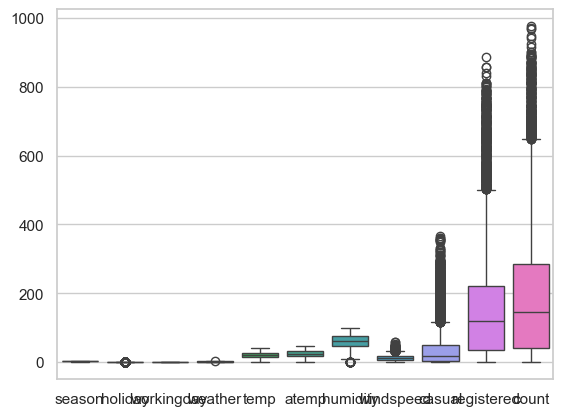

In [81]:

sns.boxplot(data=df_numeric, )

In [82]:
# sns.pairplot(df_numeric, diag_kind='kde', plot_kws={'alpha':0.5, 's':20, 'edgecolor':'k'}, height=2)

<Axes: >

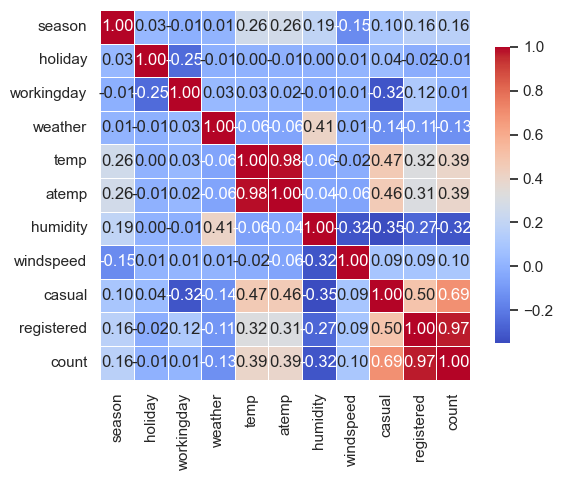

In [83]:
corr = df_numeric.corr()
corr
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink':0.8}, linewidths=0.5)

In [84]:
df["season"].value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

<Axes: xlabel='atemp', ylabel='Count'>

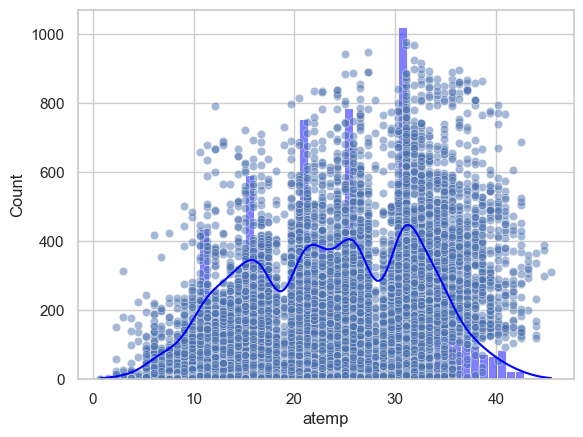

In [85]:
sns.histplot(df["atemp"], bins=50,kde=True, color='blue', alpha=0.5)
sns.scatterplot(data=df, x='atemp', y='count', alpha=0.5)

<Axes: ylabel='Count'>

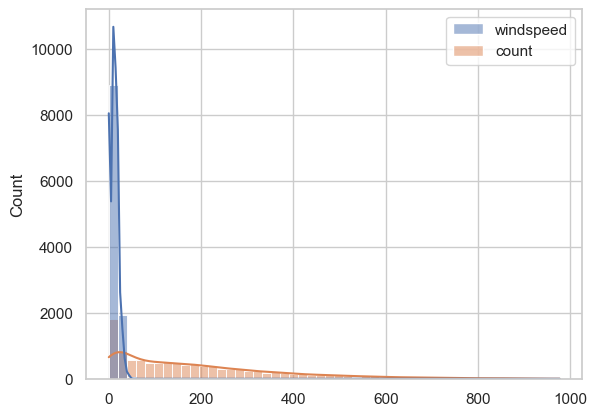

In [86]:
sns.histplot(df[["windspeed","count"]], bins=50,kde=True, color='blue', alpha=0.5)

In [87]:
df.shape

(10886, 12)

In [88]:
low_bound = df["windspeed"].quantile(0.25)
high_bound = df["windspeed"].quantile(0.75)
irq = high_bound - low_bound
msk = (df["windspeed"] < (low_bound - 1.5 * irq)) | (df["windspeed"] > (high_bound + 1.5 * irq))
msk.sum()
# df.shape[0] - msk.sum()

np.int64(227)

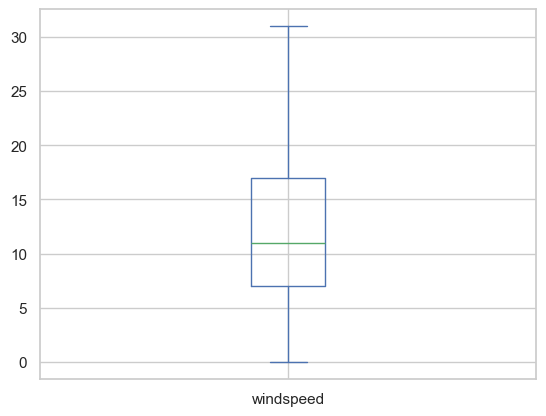

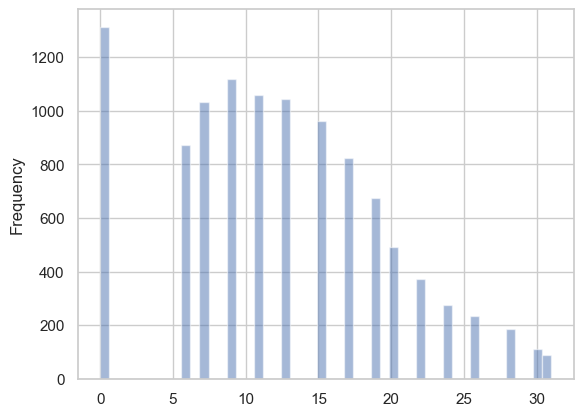

In [89]:
df[~msk]["windspeed"].plot.box()
plt.show()
df[~msk]["windspeed"].plot.hist(bins=50, alpha=0.5)
plt.show()

/Users/qiyunge/winMac/SoftwareDev/LaselleCollege/3_C2_gestion_de_données_avancé/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: ylabel='Count'>

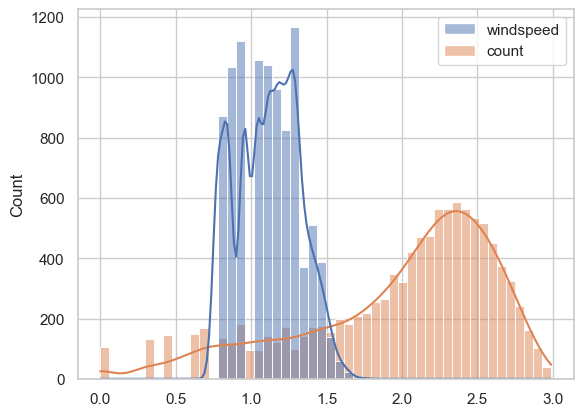

In [90]:
df["windspeed"] = np.log10(df["windspeed"])
df["count"] = np.log10(df["count"])
sns.histplot(df[["windspeed","count"]], bins=50,kde=True, color='blue', alpha=0.5)

<Axes: xlabel='registered', ylabel='count'>

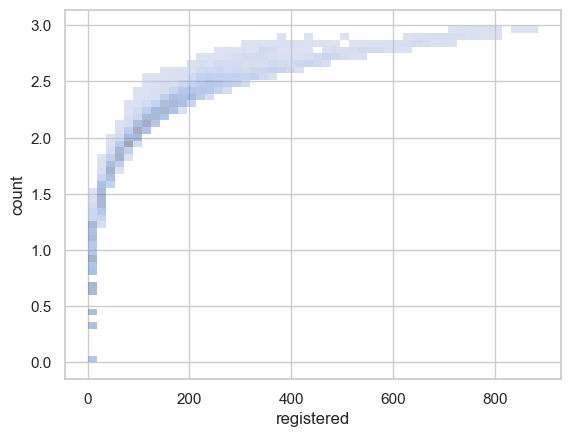

In [92]:
sns.histplot(data=df, x="registered", y="count", bins=50, alpha=0.5)